# Car Crash Severity Prediction

in this notebook we are going to try to predict how serious a car crash is using different machine learning models. the target column is `Severity` which has three values: Minor Injury, Severe Injury, and Fatal.

we will go through the data, clean it, try all the models we learned in class, and for each model we will test four different settings to see how balancing the data affects the results. then we pick the best one to submit to kaggle.

## Imports

first we import all the libraries we need.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# imblearn is a library for handling imbalanced datasets
# SMOTE creates new synthetic samples for the minority classes
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## Load the Data

In [2]:
train = pd.read_csv('car_crash_train.csv')
test  = pd.read_csv('car_crash_test.csv')
sub   = pd.read_csv('sample_submission.csv')

print('train shape:', train.shape)
print('test shape: ', test.shape)
print('submission rows:', len(sub))

train shape: (4000, 19)
test shape:  (1000, 19)
submission rows: 5000


In [3]:
train.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

In [5]:
train.describe()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


## Exploratory Data Analysis (EDA)

before building any models we need to understand the data first. we look at the distribution of the target, check for missing values, and explore how features relate to crash severity.

### Target Distribution

In [6]:
print(train['Severity'].value_counts())
print()
print(train['Severity'].value_counts(normalize=True).round(3))

Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64

Severity
Minor Injury     0.689
Severe Injury    0.260
Fatal            0.052
Name: proportion, dtype: float64


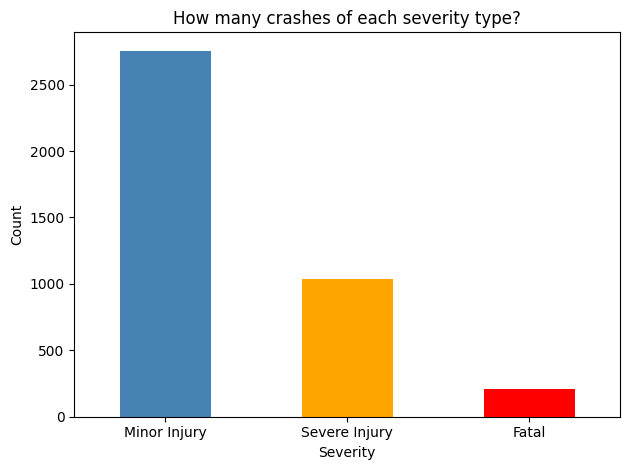

In [7]:
train['Severity'].value_counts().plot(kind='bar', color=['steelblue','orange','red'])
plt.title('How many crashes of each severity type?')
plt.ylabel('Count')
plt.xlabel('Severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

we can see that most crashes are Minor Injury (~69%), Severe Injury is ~25%, and Fatal is only ~5%. this is called **class imbalance**.

this is a big problem because a model can get ~71% accuracy just by always predicting Minor Injury — without learning anything useful about Severe and Fatal crashes. in real life, missing a Fatal crash is much more serious than getting a Minor Injury wrong, so accuracy alone is not a good metric here. we will also use Macro F1 score which treats all classes equally and punishes the model if it ignores the minority classes.

we will try three balancing strategies for each model to see if we can do better on F1.

### Missing Values

In [8]:
print('Train missing values:')
print(train.isnull().sum()[train.isnull().sum() > 0])
print()
print('Test missing values:')
print(test.isnull().sum()[test.isnull().sum() > 0])

Train missing values:
Distraction Level    2360
dtype: int64

Test missing values:
Distraction Level    603
dtype: int64


only `Distraction Level` has missing values — about 59% in training. we fill with `'Unknown'` because not having distraction info is still useful info.

### Numerical Features

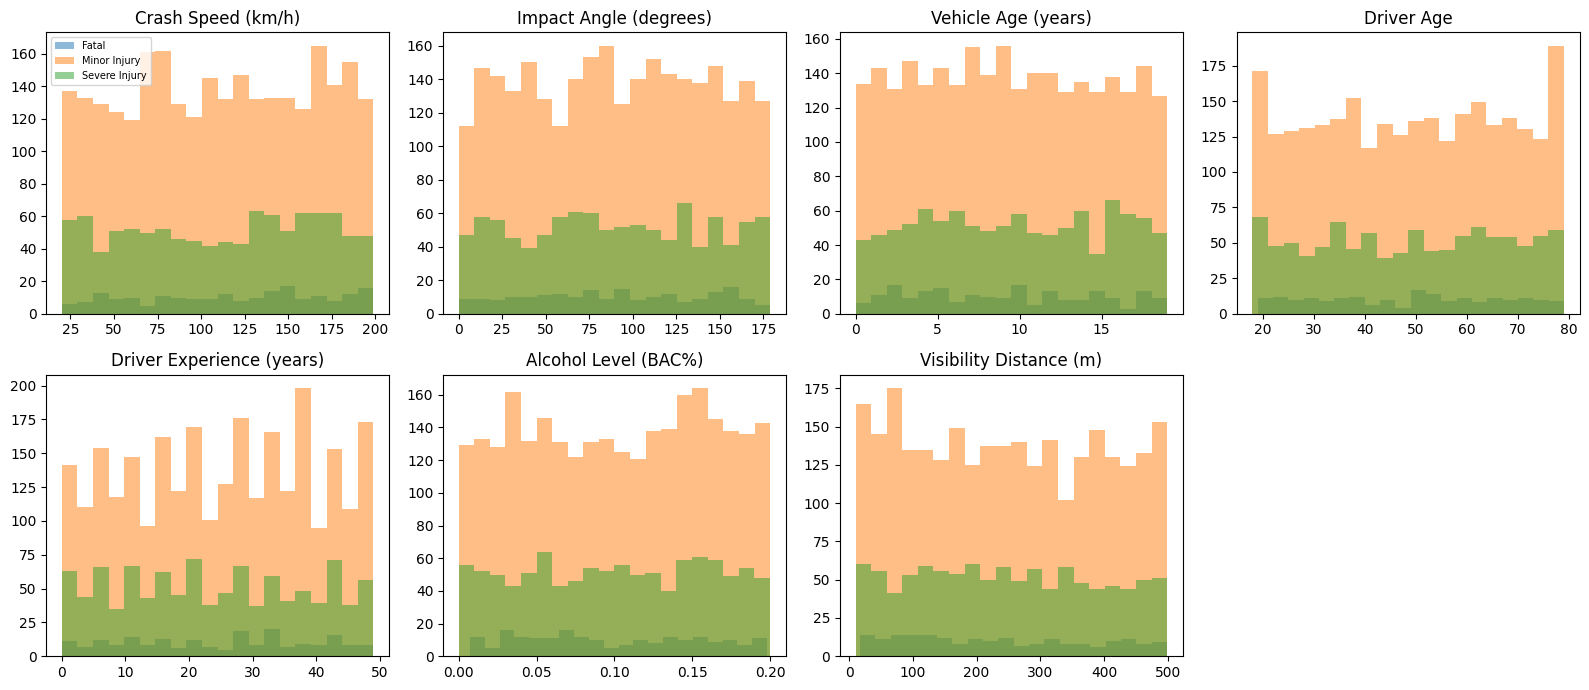

In [9]:
num_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
            'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
            'Visibility Distance (m)']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for sev, grp in train.groupby('Severity'):
        axes[i].hist(grp[col], bins=20, alpha=0.5, label=sev)
    axes[i].set_title(col)
    if i == 0:
        axes[i].legend(fontsize=7)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

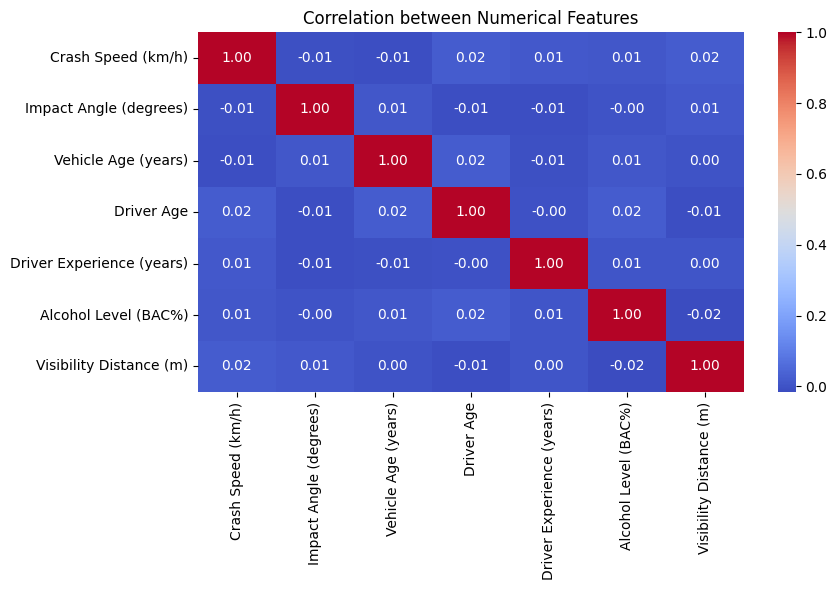

In [10]:
plt.figure(figsize=(9, 6))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between Numerical Features')
plt.tight_layout()
plt.show()

### Crash Speed and Alcohol Level vs Severity

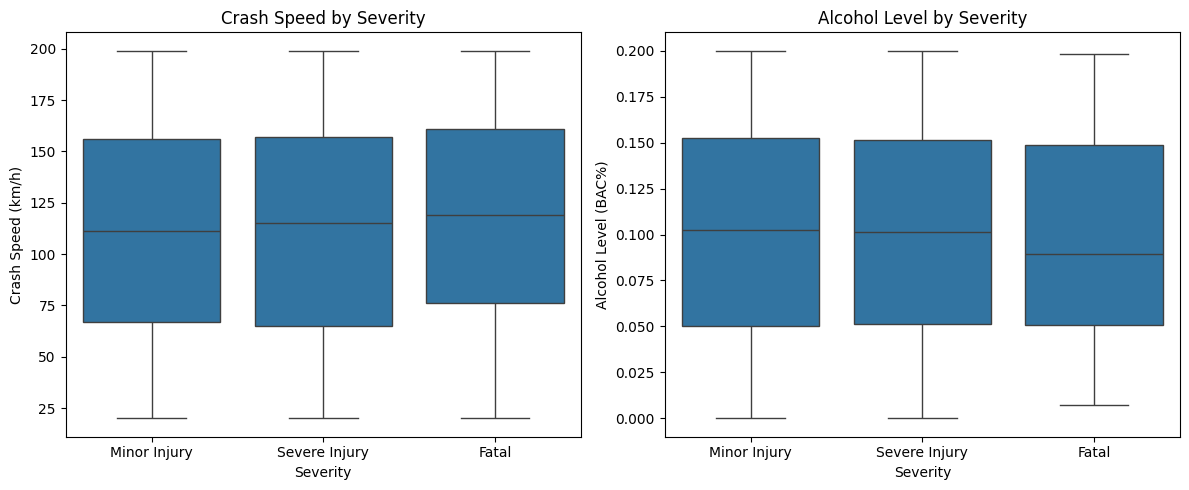

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ['Minor Injury', 'Severe Injury', 'Fatal']
sns.boxplot(data=train, x='Severity', y='Crash Speed (km/h)', order=order, ax=axes[0])
axes[0].set_title('Crash Speed by Severity')
sns.boxplot(data=train, x='Severity', y='Alcohol Level (BAC%)', order=order, ax=axes[1])
axes[1].set_title('Alcohol Level by Severity')
plt.tight_layout()
plt.show()

### Categorical Features vs Severity

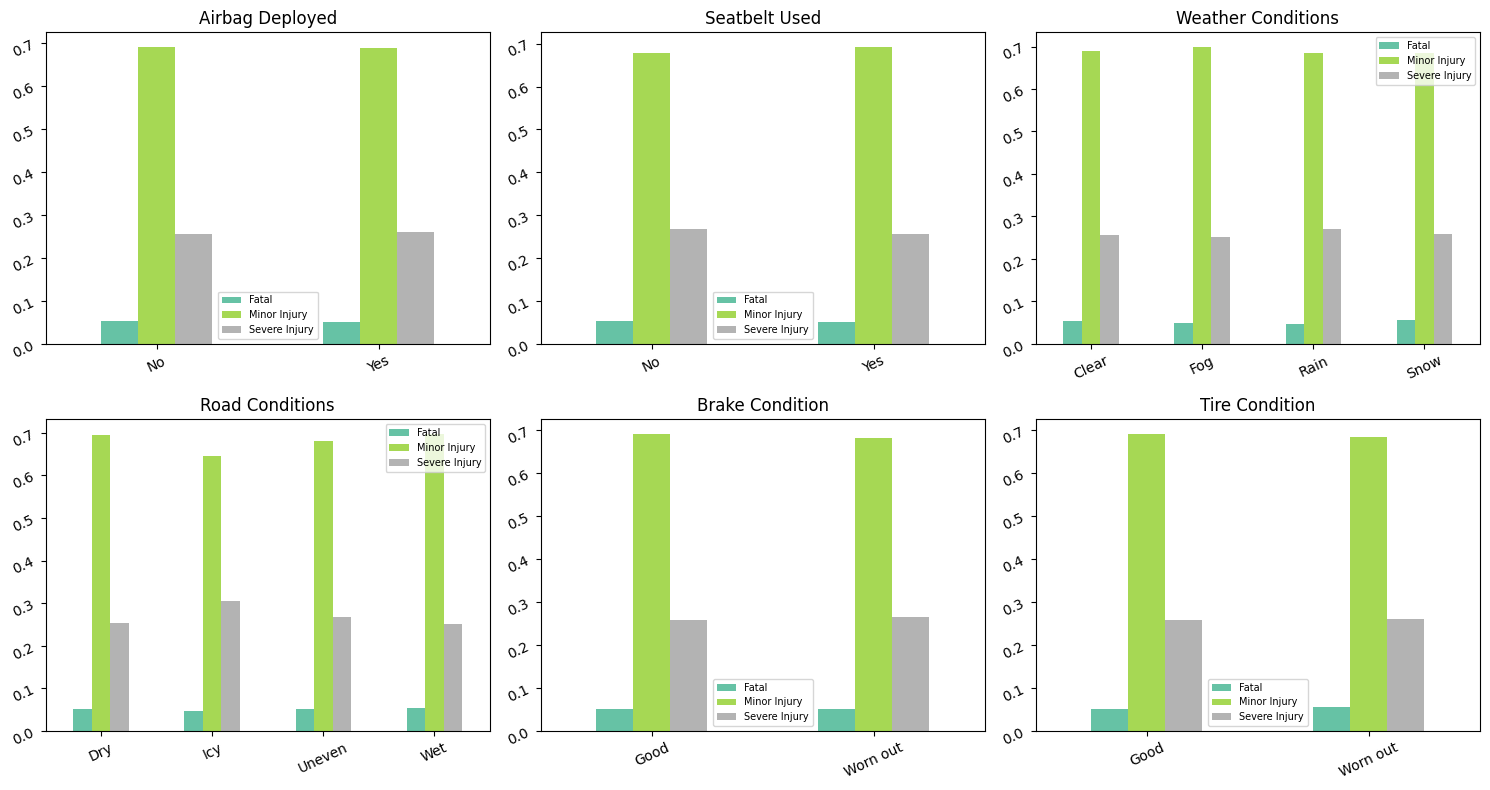

In [12]:
cat_plot_cols = ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
                 'Road Conditions', 'Brake Condition', 'Tire Condition']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_plot_cols):
    ct = pd.crosstab(train[col], train['Severity'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], colormap='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(rotation=25)
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

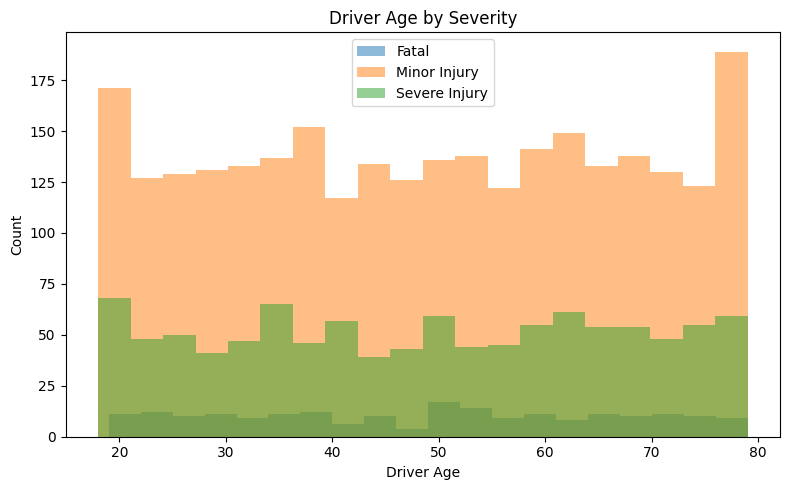

In [13]:
plt.figure(figsize=(8, 5))
for sev, grp in train.groupby('Severity'):
    plt.hist(grp['Driver Age'], bins=20, alpha=0.5, label=sev)
plt.title('Driver Age by Severity')
plt.xlabel('Driver Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Preprocessing

we need to prepare the data before giving it to any model:
- fill missing values
- convert text columns to numbers
- scale features for models that need it

### Fill Missing Values

In [14]:
train['Distraction Level'] = train['Distraction Level'].fillna('Unknown')
test['Distraction Level']  = test['Distraction Level'].fillna('Unknown')

print('Missing after fill - train:', train.isnull().sum().sum())
print('Missing after fill - test: ', test.isnull().sum().sum())

Missing after fill - train: 0
Missing after fill - test:  0


### Encode Categorical Columns

In [15]:
from sklearn.preprocessing import LabelEncoder

all_cat = ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions',
           'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition',
           'Distraction Level', 'Time of Day', 'Traffic Density']

# fit on train only, then apply same mapping to test to avoid data leakage
le_dict = {}
for col in all_cat:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col]  = le.transform(test[col])
    le_dict[col] = le

train.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,1,0,0,0,2,2,5,0,0,23,11,0.025314,3,1,1,213,Minor Injury
1,192,73,1,0,0,0,0,3,3,0,0,29,27,0.002372,2,1,2,426,Minor Injury
2,114,77,0,1,0,0,0,2,16,0,1,73,45,0.000483,3,1,2,175,Minor Injury
3,93,14,0,1,0,0,1,3,14,1,1,27,18,0.176578,3,0,2,82,Minor Injury
4,170,96,0,1,0,0,3,1,15,0,0,70,27,0.065696,1,1,2,96,Severe Injury


### Separate Features and Labels

In [16]:
X_train = train.drop('Severity', axis=1)
y_train = train['Severity']

# y_test is only used for evaluation, never for training
X_test = test.drop('Severity', axis=1)
y_test = test['Severity']

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (4000, 18)
X_test:  (1000, 18)


### Scale Features

In [17]:
from sklearn.preprocessing import StandardScaler

# fit on train only, transform both
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

### About the Four Settings We Test Per Model

for every model we will try four settings:

1. **Default** — normal training, same as before, optimizes for accuracy
2. **SMOTE** — we create fake extra samples for Severe Injury and Fatal so the model sees more examples of the rare classes. we do this inside cross validation using a Pipeline so the test data never gets touched
3. **class_weight='balanced'** — instead of oversampling, we tell the model to care more about mistakes on the minority classes (not available for KNN, Naive Bayes, Gradient Boosting)
4. **F1-optimized** — same grid search but we score by macro F1 instead of accuracy, so grid search picks the model that works best on all three classes equally

we will see that improving F1 sometimes means accepting a slight drop in accuracy. this is the trade-off we have to deal with in imbalanced problems.

### Evaluation Function

In [18]:
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              accuracy_score, f1_score)

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'=== {name} ===')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Macro F1:  {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()
    return acc, f1

## 1. K-Nearest Neighbors (KNN)

KNN makes a prediction by looking at the K nearest training samples and taking a vote. we use a Pipeline with StandardScaler so the scaling is done correctly inside cross validation. note: KNN does not have a class_weight parameter, so we only test 3 settings here.

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

### Setting 1: Default (optimizes accuracy)

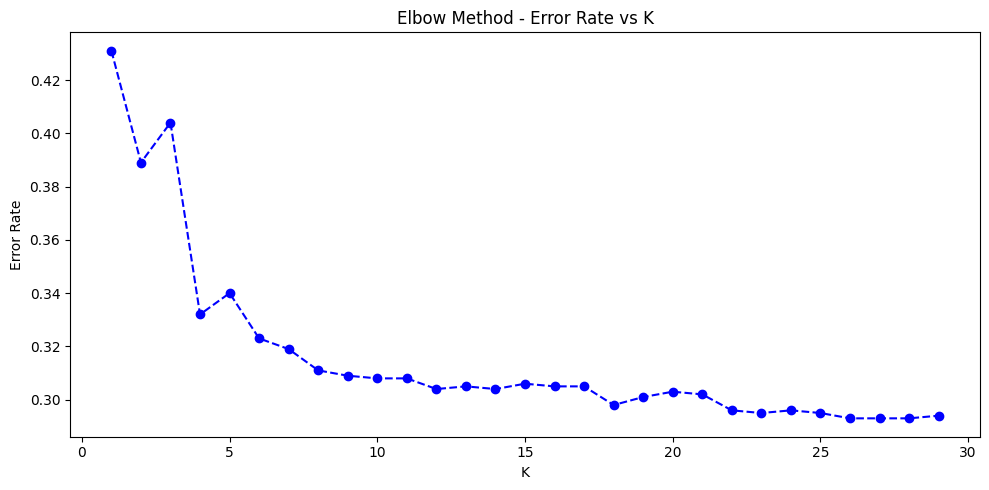

In [20]:
# elbow plot — we want to see the error rate for each K
error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    preds_k = knn.predict(X_test_sc)
    error_rates.append(1 - accuracy_score(y_test, preds_k))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 30), error_rates, marker='o', color='blue', linestyle='--')
plt.title('Elbow Method - Error Rate vs K')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.tight_layout()
plt.show()

In [21]:
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
knn_params = {'knn__n_neighbors': list(range(1, 30))}

knn_grid = GridSearchCV(knn_pipe, knn_params, cv=5)
knn_grid.fit(X_train, y_train)

print('Best k:', knn_grid.best_params_)
print('Best CV accuracy:', round(knn_grid.best_score_, 4))

Best k: {'knn__n_neighbors': 28}
Best CV accuracy: 0.687


=== KNN - Default ===
Accuracy:  0.7070
Macro F1:  0.2761

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



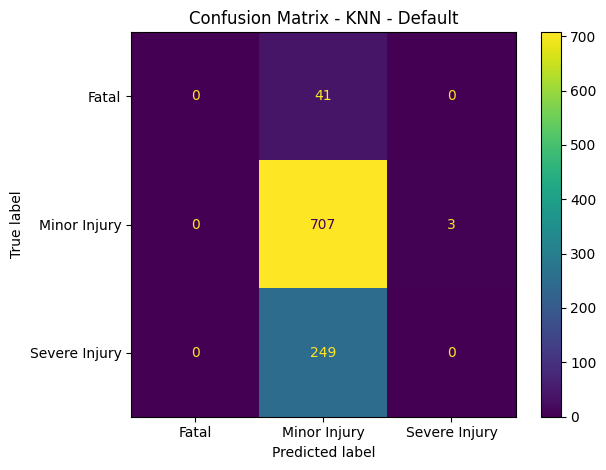

In [22]:
knn_preds = knn_grid.predict(X_test)
knn_acc, knn_f1 = evaluate('KNN - Default', y_test, knn_preds)

### Setting 2: with SMOTE Oversampling

SMOTE creates synthetic new samples for Severe Injury and Fatal by interpolating between existing samples. this gives the model more examples of the rare classes to learn from. we do this inside the pipeline so SMOTE only applies to training folds during cross validation.

In [23]:
# ImbPipeline supports SMOTE as a step, regular Pipeline does not
knn_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_smote_params = {'knn__n_neighbors': list(range(1, 20))}
knn_smote_grid = GridSearchCV(knn_smote_pipe, knn_smote_params, cv=5)
knn_smote_grid.fit(X_train, y_train)

print('Best k with SMOTE:', knn_smote_grid.best_params_)
print('Best CV accuracy: ', round(knn_smote_grid.best_score_, 4))

Best k with SMOTE: {'knn__n_neighbors': 2}
Best CV accuracy:  0.445


=== KNN - SMOTE ===
Accuracy:  0.4790
Macro F1:  0.3055

               precision    recall  f1-score   support

        Fatal       0.05      0.29      0.08        41
 Minor Injury       0.70      0.61      0.65       710
Severe Injury       0.25      0.14      0.18       249

     accuracy                           0.48      1000
    macro avg       0.33      0.35      0.31      1000
 weighted avg       0.57      0.48      0.51      1000



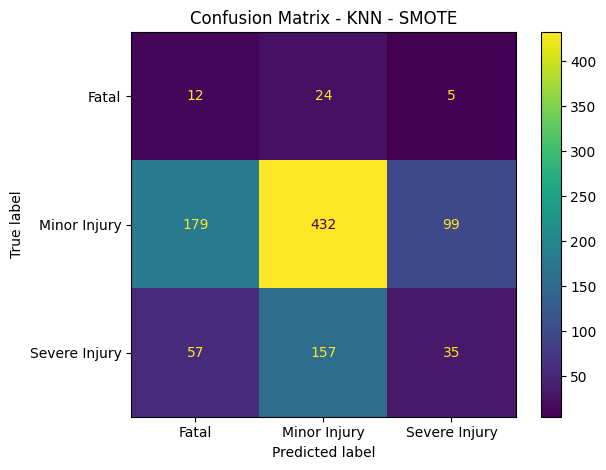

In [24]:
knn_smote_preds = knn_smote_grid.predict(X_test)
knn_smote_acc, knn_smote_f1 = evaluate('KNN - SMOTE', y_test, knn_smote_preds)

### Setting 3: GridSearch Optimized for F1 Score

we run the same grid search but now we tell it to pick the K that gives the best macro F1 instead of best accuracy. this should help the model care more about the minority classes.

In [25]:
knn_f1_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
knn_f1_params = {'knn__n_neighbors': list(range(1, 20))}

# the only difference from default is scoring='f1_macro' here
knn_f1_grid = GridSearchCV(knn_f1_pipe, knn_f1_params, cv=5, scoring='f1_macro')
knn_f1_grid.fit(X_train, y_train)

print('Best k for F1:', knn_f1_grid.best_params_)
print('Best CV macro F1:', round(knn_f1_grid.best_score_, 4))

Best k for F1: {'knn__n_neighbors': 1}
Best CV macro F1: 0.3282


=== KNN - F1 Optimized ===
Accuracy:  0.5690
Macro F1:  0.3620

               precision    recall  f1-score   support

        Fatal       0.13      0.15      0.14        41
 Minor Injury       0.71      0.71      0.71       710
Severe Injury       0.25      0.24      0.24       249

     accuracy                           0.57      1000
    macro avg       0.36      0.36      0.36      1000
 weighted avg       0.57      0.57      0.57      1000



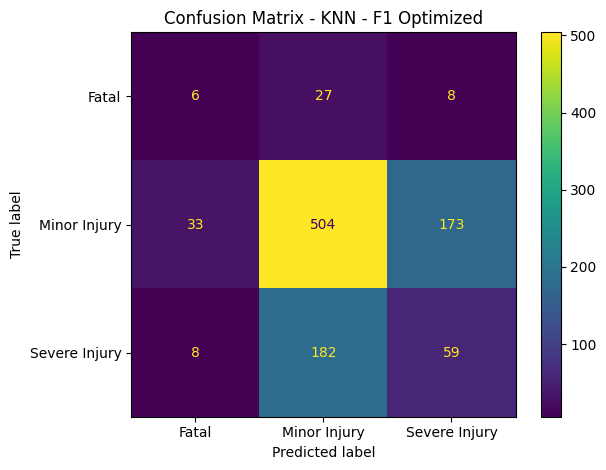

In [26]:
knn_f1_preds = knn_f1_grid.predict(X_test)
knn_f1_acc, knn_f1_f1 = evaluate('KNN - F1 Optimized', y_test, knn_f1_preds)

### KNN Summary

KNN does not support class_weight so we only have three settings here.

In [27]:
knn_summary = pd.DataFrame({
    'Setting':  ['Default', 'SMOTE', 'F1 Optimized'],
    'Accuracy': [knn_acc, knn_smote_acc, knn_f1_acc],
    'Macro F1': [knn_f1, knn_smote_f1, knn_f1_f1]
})
print(knn_summary.round(4).to_string(index=False))

     Setting  Accuracy  Macro F1
     Default     0.707    0.2761
       SMOTE     0.479    0.3055
F1 Optimized     0.569    0.3620


## 2. Decision Tree

a decision tree splits the data by asking yes/no questions about feature values. this model supports class_weight so we test all four settings.

In [28]:
from sklearn.tree import DecisionTreeClassifier

### Setting 1: Default (optimizes accuracy)

In [29]:
dt_params = {
    'max_depth': [None, 3, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5)
dt_grid.fit(X_train, y_train)

print('Best params:', dt_grid.best_params_)
print('Best CV accuracy:', round(dt_grid.best_score_, 4))

Best params: {'criterion': 'entropy', 'max_depth': 3}
Best CV accuracy: 0.6875


=== Decision Tree - Default ===
Accuracy:  0.7110
Macro F1:  0.2796

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       1.00      0.00      0.01       249

     accuracy                           0.71      1000
    macro avg       0.57      0.33      0.28      1000
 weighted avg       0.75      0.71      0.59      1000



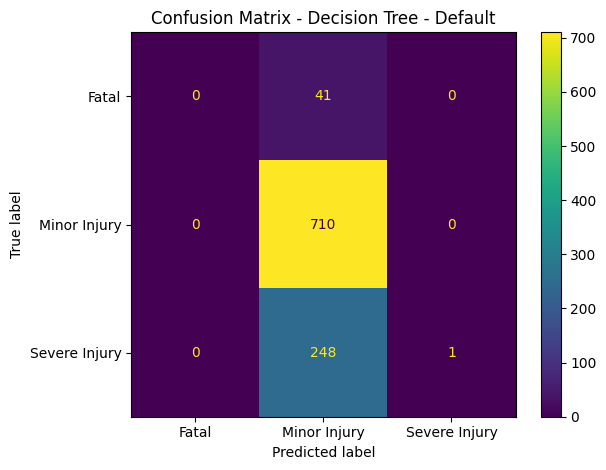

In [30]:
dt_preds = dt_grid.predict(X_test)
dt_acc, dt_f1 = evaluate('Decision Tree - Default', y_test, dt_preds)

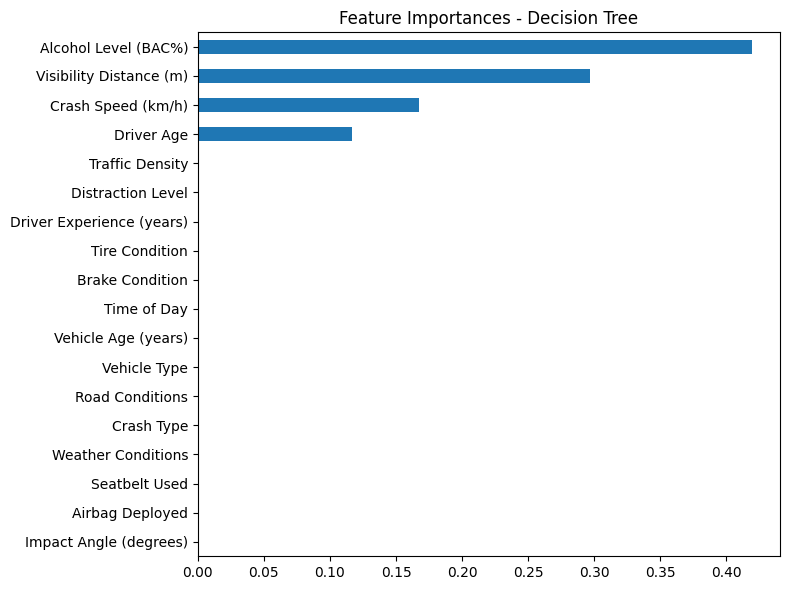

In [31]:
importances = pd.Series(
    dt_grid.best_estimator_.feature_importances_, index=X_train.columns
).sort_values()
importances.plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

### Setting 2: with SMOTE Oversampling

In [32]:
dt_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# prefix 'dt__' so GridSearchCV knows these params belong to the dt step
dt_smote_params = {'dt__max_depth': [None, 3, 5, 10], 'dt__criterion': ['gini', 'entropy']}
dt_smote_grid = GridSearchCV(dt_smote_pipe, dt_smote_params, cv=5)
dt_smote_grid.fit(X_train, y_train)

print('Best params with SMOTE:', dt_smote_grid.best_params_)
print('Best CV accuracy:       ', round(dt_smote_grid.best_score_, 4))

Best params with SMOTE: {'dt__criterion': 'entropy', 'dt__max_depth': 5}
Best CV accuracy:        0.4833


=== Decision Tree - SMOTE ===
Accuracy:  0.4880
Macro F1:  0.2916

               precision    recall  f1-score   support

        Fatal       0.03      0.15      0.05        41
 Minor Injury       0.69      0.63      0.66       710
Severe Injury       0.22      0.13      0.16       249

     accuracy                           0.49      1000
    macro avg       0.31      0.30      0.29      1000
 weighted avg       0.55      0.49      0.51      1000



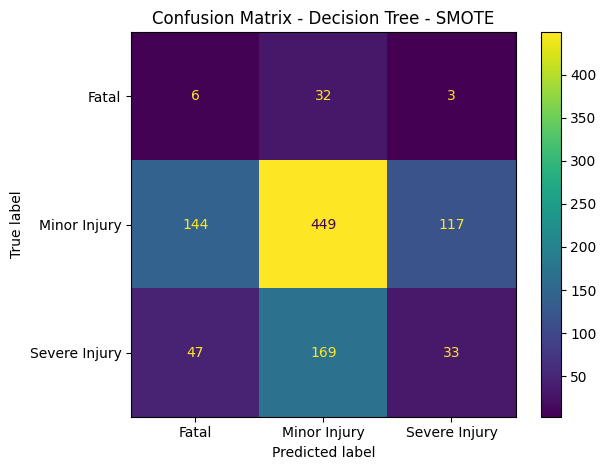

In [33]:
dt_smote_preds = dt_smote_grid.predict(X_test)
dt_smote_acc, dt_smote_f1 = evaluate('Decision Tree - SMOTE', y_test, dt_smote_preds)

### Setting 3: with class_weight='balanced'

instead of creating new samples, we tell the model to put more weight on errors in the minority classes. internally sklearn adjusts the split criterion to penalize misclassifying Fatal and Severe Injury more than Minor Injury.

In [34]:
# we add class_weight='balanced' to the param grid
dt_cw_params = {
    'max_depth': [None, 3, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}
dt_cw_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_cw_params, cv=5)
dt_cw_grid.fit(X_train, y_train)

print('Best params with class_weight:', dt_cw_grid.best_params_)
print('Best CV accuracy:              ', round(dt_cw_grid.best_score_, 4))

Best params with class_weight: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None}
Best CV accuracy:               0.5312


=== Decision Tree - class_weight balanced ===
Accuracy:  0.5710
Macro F1:  0.3304

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.72      0.71      0.72       710
Severe Injury       0.27      0.28      0.28       249

     accuracy                           0.57      1000
    macro avg       0.33      0.33      0.33      1000
 weighted avg       0.58      0.57      0.58      1000



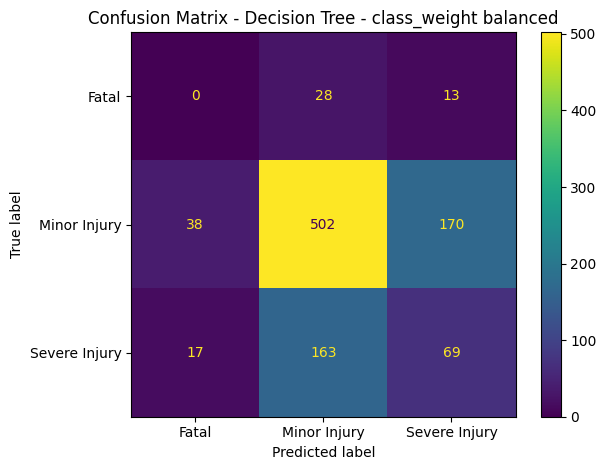

In [35]:
dt_cw_preds = dt_cw_grid.predict(X_test)
dt_cw_acc, dt_cw_f1 = evaluate('Decision Tree - class_weight balanced', y_test, dt_cw_preds)

### Setting 4: GridSearch Optimized for F1 Score

In [36]:
dt_f1_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          dt_params, cv=5, scoring='f1_macro')
dt_f1_grid.fit(X_train, y_train)

print('Best params for F1:', dt_f1_grid.best_params_)
print('Best CV macro F1:  ', round(dt_f1_grid.best_score_, 4))

Best params for F1: {'criterion': 'entropy', 'max_depth': None}
Best CV macro F1:   0.3444


=== Decision Tree - F1 Optimized ===
Accuracy:  0.5700
Macro F1:  0.3420

               precision    recall  f1-score   support

        Fatal       0.04      0.05      0.04        41
 Minor Injury       0.72      0.70      0.71       710
Severe Injury       0.27      0.27      0.27       249

     accuracy                           0.57      1000
    macro avg       0.34      0.34      0.34      1000
 weighted avg       0.58      0.57      0.58      1000



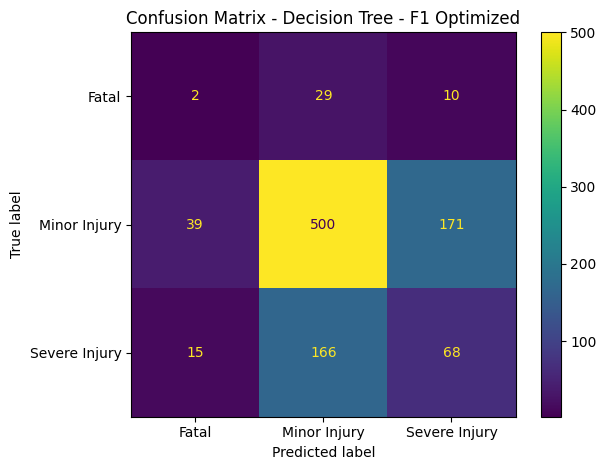

In [37]:
dt_f1_preds = dt_f1_grid.predict(X_test)
dt_f1_acc, dt_f1_f1 = evaluate('Decision Tree - F1 Optimized', y_test, dt_f1_preds)

In [38]:
dt_summary = pd.DataFrame({
    'Setting':  ['Default', 'SMOTE', 'class_weight balanced', 'F1 Optimized'],
    'Accuracy': [dt_acc, dt_smote_acc, dt_cw_acc, dt_f1_acc],
    'Macro F1': [dt_f1, dt_smote_f1, dt_cw_f1, dt_f1_f1]
})
print('Decision Tree - All Settings')
print(dt_summary.round(4).to_string(index=False))

Decision Tree - All Settings
              Setting  Accuracy  Macro F1
              Default     0.711    0.2796
                SMOTE     0.488    0.2916
class_weight balanced     0.571    0.3304
         F1 Optimized     0.570    0.3420


## 3. Random Forest

random forest builds many decision trees and combines their votes. it supports class_weight so we test all four settings.

In [39]:
from sklearn.ensemble import RandomForestClassifier

### Setting 1: Default (optimizes accuracy)

In [40]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid.fit(X_train, y_train)

print('Best params:', rf_grid.best_params_)
print('Best CV accuracy:', round(rf_grid.best_score_, 4))

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Best CV accuracy: 0.6892


=== Random Forest - Default ===
Accuracy:  0.7100
Macro F1:  0.2768

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



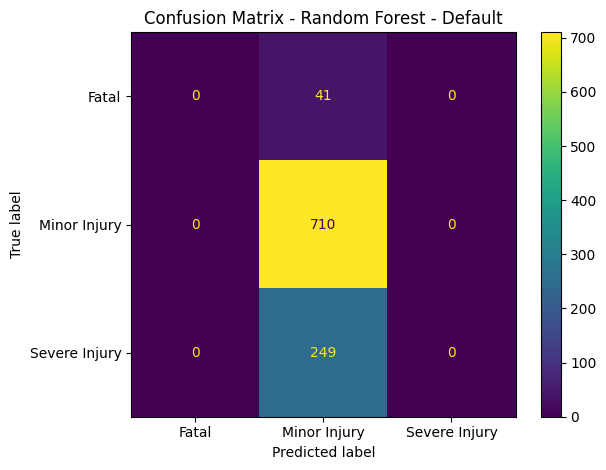

In [41]:
rf_preds = rf_grid.predict(X_test)
rf_acc, rf_f1 = evaluate('Random Forest - Default', y_test, rf_preds)

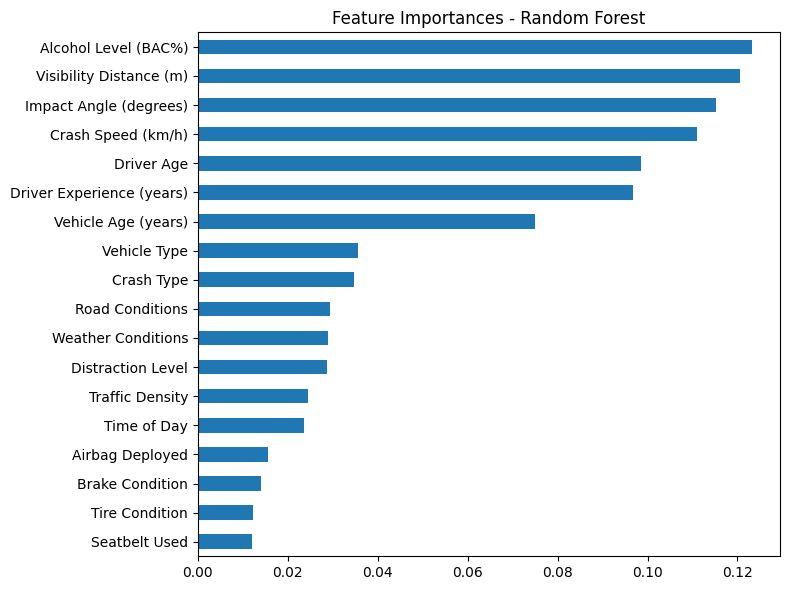

In [42]:
rf_importances = pd.Series(
    rf_grid.best_estimator_.feature_importances_, index=X_train.columns
).sort_values()
rf_importances.plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

### Setting 2: with SMOTE Oversampling

In [43]:
rf_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])
rf_smote_params = {'rf__n_estimators': [50, 100], 'rf__max_depth': [None, 5, 10],
                   'rf__max_features': ['sqrt']}
rf_smote_grid = GridSearchCV(rf_smote_pipe, rf_smote_params, cv=5)
rf_smote_grid.fit(X_train, y_train)

print('Best params with SMOTE:', rf_smote_grid.best_params_)
print('Best CV accuracy:       ', round(rf_smote_grid.best_score_, 4))

Best params with SMOTE: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__n_estimators': 100}
Best CV accuracy:        0.595


=== Random Forest - SMOTE ===
Accuracy:  0.5930
Macro F1:  0.2999

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.70      0.79      0.74       710
Severe Injury       0.19      0.13      0.16       249

     accuracy                           0.59      1000
    macro avg       0.30      0.31      0.30      1000
 weighted avg       0.55      0.59      0.57      1000



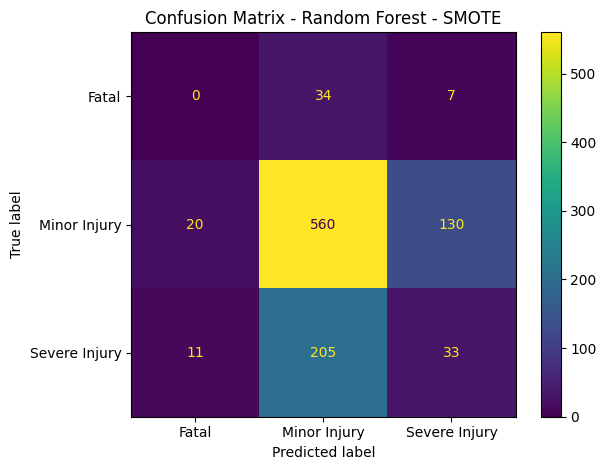

In [44]:
rf_smote_preds = rf_smote_grid.predict(X_test)
rf_smote_acc, rf_smote_f1 = evaluate('Random Forest - SMOTE', y_test, rf_smote_preds)

### Setting 3: with class_weight='balanced'

In [45]:
rf_cw_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}
rf_cw_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_cw_params, cv=5)
rf_cw_grid.fit(X_train, y_train)

print('Best params with class_weight:', rf_cw_grid.best_params_)
print('Best CV accuracy:              ', round(rf_cw_grid.best_score_, 4))

Best params with class_weight: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV accuracy:               0.6882


=== Random Forest - class_weight balanced ===
Accuracy:  0.7090
Macro F1:  0.2766

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



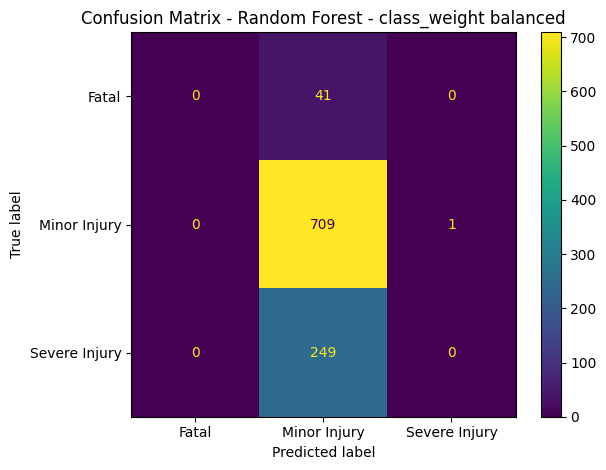

In [46]:
rf_cw_preds = rf_cw_grid.predict(X_test)
rf_cw_acc, rf_cw_f1 = evaluate('Random Forest - class_weight balanced', y_test, rf_cw_preds)

### Setting 4: GridSearch Optimized for F1 Score

In [47]:
rf_f1_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                          rf_params, cv=5, scoring='f1_macro')
rf_f1_grid.fit(X_train, y_train)

print('Best params for F1:', rf_f1_grid.best_params_)
print('Best CV macro F1:  ', round(rf_f1_grid.best_score_, 4))

Best params for F1: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
Best CV macro F1:   0.2799


=== Random Forest - F1 Optimized ===
Accuracy:  0.7110
Macro F1:  0.2872

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.57      0.02      0.03       249

     accuracy                           0.71      1000
    macro avg       0.43      0.34      0.29      1000
 weighted avg       0.65      0.71      0.60      1000



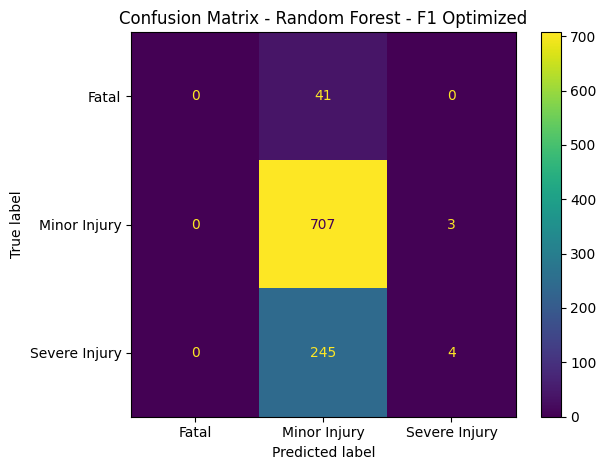

In [48]:
rf_f1_preds = rf_f1_grid.predict(X_test)
rf_f1_acc, rf_f1_f1 = evaluate('Random Forest - F1 Optimized', y_test, rf_f1_preds)

In [49]:
rf_summary = pd.DataFrame({
    'Setting':  ['Default', 'SMOTE', 'class_weight balanced', 'F1 Optimized'],
    'Accuracy': [rf_acc, rf_smote_acc, rf_cw_acc, rf_f1_acc],
    'Macro F1': [rf_f1, rf_smote_f1, rf_cw_f1, rf_f1_f1]
})
print('Random Forest - All Settings')
print(rf_summary.round(4).to_string(index=False))

Random Forest - All Settings
              Setting  Accuracy  Macro F1
              Default     0.710    0.2768
                SMOTE     0.593    0.2999
class_weight balanced     0.709    0.2766
         F1 Optimized     0.711    0.2872


## 4. Logistic Regression

logistic regression learns a linear decision boundary between classes. it supports class_weight so we test all four settings. all settings use scaled data since logistic regression is sensitive to feature scale.

In [50]:
from sklearn.linear_model import LogisticRegression

### Setting 1: Default (optimizes accuracy)

In [51]:
# no grid search here since we only have C to tune and default works fine
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_sc, y_train)

LogisticRegression(max_iter=1000, random_state=42)

=== Logistic Regression - Default ===
Accuracy:  0.7100
Macro F1:  0.2768

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



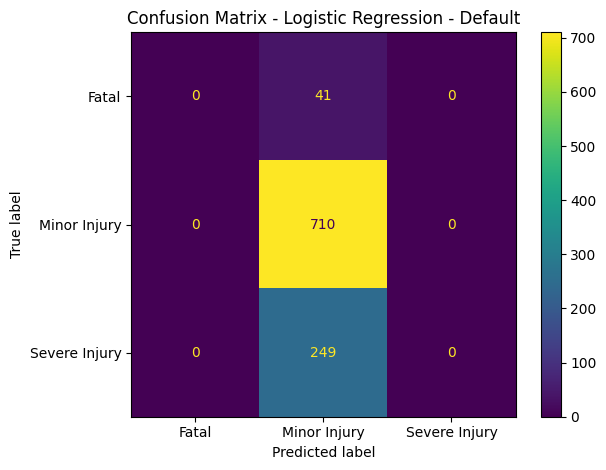

In [52]:
log_preds = log_model.predict(X_test_sc)
log_acc, log_f1 = evaluate('Logistic Regression - Default', y_test, log_preds)

In [53]:
coef_df = pd.DataFrame(log_model.coef_, columns=X_train.columns,
                        index=log_model.classes_)
coef_df

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m)
Fatal,0.080860,0.001999,-0.014710,-0.011123,-0.012138,0.003651,-0.023565,0.006997,-0.049363,0.001285,0.026303,-0.020437,0.010218,-0.022130,-0.011481,-0.037975,0.018108,-0.058824
Minor Injury,-0.044731,0.000439,0.002368,0.018097,-0.001440,-0.005891,-0.001146,-0.008731,0.005463,-0.006808,-0.016045,0.012127,0.027052,0.019151,0.003971,-0.003460,0.016208,0.033515
Severe Injury,-0.036129,-0.002437,0.012342,-0.006974,0.013578,0.002240,0.024711,0.001735,0.043900,0.005523,-0.010258,0.008310,-0.037269,0.002979,0.007510,0.041436,-0.034316,0.025309


### Setting 2: with SMOTE Oversampling

In [54]:
lr_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
lr_smote_grid = GridSearchCV(lr_smote_pipe, {'lr__C': [0.01, 0.1, 1, 10]}, cv=5)
lr_smote_grid.fit(X_train, y_train)

print('Best C with SMOTE:', lr_smote_grid.best_params_)
print('Best CV accuracy: ', round(lr_smote_grid.best_score_, 4))

Best C with SMOTE: {'lr__C': 0.01}
Best CV accuracy:  0.4858


=== Logistic Regression - SMOTE ===
Accuracy:  0.4950
Macro F1:  0.3147

               precision    recall  f1-score   support

        Fatal       0.05      0.24      0.09        41
 Minor Injury       0.71      0.62      0.66       710
Severe Injury       0.23      0.17      0.20       249

     accuracy                           0.49      1000
    macro avg       0.33      0.35      0.31      1000
 weighted avg       0.56      0.49      0.52      1000



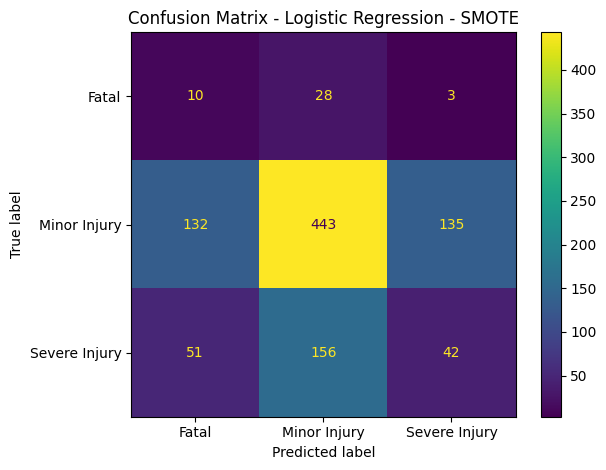

In [55]:
lr_smote_preds = lr_smote_grid.predict(X_test)
lr_smote_acc, lr_smote_f1 = evaluate('Logistic Regression - SMOTE', y_test, lr_smote_preds)

### Setting 3: with class_weight='balanced'

In [56]:
# class_weight='balanced' makes the model weight each class proportionally
# to how underrepresented it is in the training data
log_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_cw.fit(X_train_sc, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

=== Logistic Regression - class_weight balanced ===
Accuracy:  0.3140
Macro F1:  0.2650

               precision    recall  f1-score   support

        Fatal       0.05      0.41      0.09        41
 Minor Injury       0.72      0.30      0.42       710
Severe Injury       0.25      0.35      0.29       249

     accuracy                           0.31      1000
    macro avg       0.34      0.35      0.26      1000
 weighted avg       0.57      0.31      0.37      1000



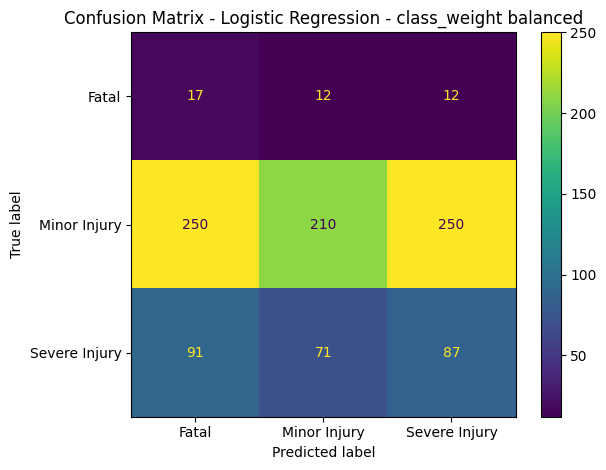

In [57]:
log_cw_preds = log_cw.predict(X_test_sc)
log_cw_acc, log_cw_f1 = evaluate('Logistic Regression - class_weight balanced', y_test, log_cw_preds)

### Setting 4: GridSearch Optimized for F1 Score

In [58]:
lr_f1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
lr_f1_grid = GridSearchCV(lr_f1_pipe, {'lr__C': [0.01, 0.1, 1, 10]},
                          cv=5, scoring='f1_macro')
lr_f1_grid.fit(X_train, y_train)

print('Best C for F1:', lr_f1_grid.best_params_)
print('Best CV macro F1:', round(lr_f1_grid.best_score_, 4))

Best C for F1: {'lr__C': 0.01}
Best CV macro F1: 0.272


=== Logistic Regression - F1 Optimized ===
Accuracy:  0.7100
Macro F1:  0.2768

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



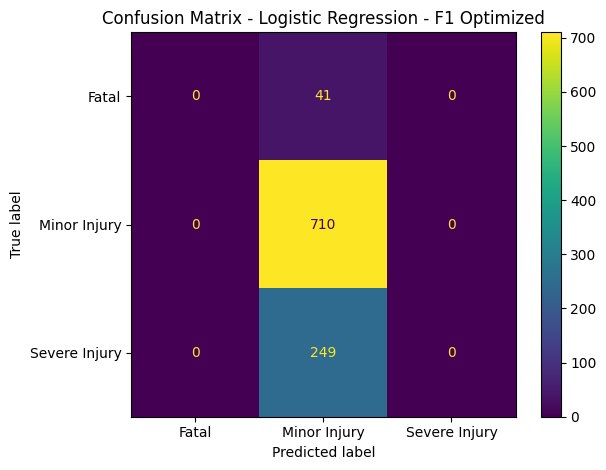

In [59]:
lr_f1_preds = lr_f1_grid.predict(X_test)
lr_f1_acc, lr_f1_f1 = evaluate('Logistic Regression - F1 Optimized', y_test, lr_f1_preds)

In [60]:
lr_summary = pd.DataFrame({
    'Setting':  ['Default', 'SMOTE', 'class_weight balanced', 'F1 Optimized'],
    'Accuracy': [log_acc, lr_smote_acc, log_cw_acc, lr_f1_acc],
    'Macro F1': [log_f1, lr_smote_f1, log_cw_f1, lr_f1_f1]
})
print('Logistic Regression - All Settings')
print(lr_summary.round(4).to_string(index=False))

Logistic Regression - All Settings
              Setting  Accuracy  Macro F1
              Default     0.710    0.2768
                SMOTE     0.495    0.3147
class_weight balanced     0.314    0.2650
         F1 Optimized     0.710    0.2768


## 5. Naive Bayes

naive bayes assumes all features are independent and follow a normal distribution within each class. it does not have a class_weight parameter, so we only test three settings here.

In [61]:
from sklearn.naive_bayes import GaussianNB

### Setting 1: Default (optimizes accuracy)

In [62]:
nb_model = GaussianNB()
nb_model.fit(X_train_sc, y_train)

GaussianNB()

=== Naive Bayes - Default ===
Accuracy:  0.7100
Macro F1:  0.2768

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



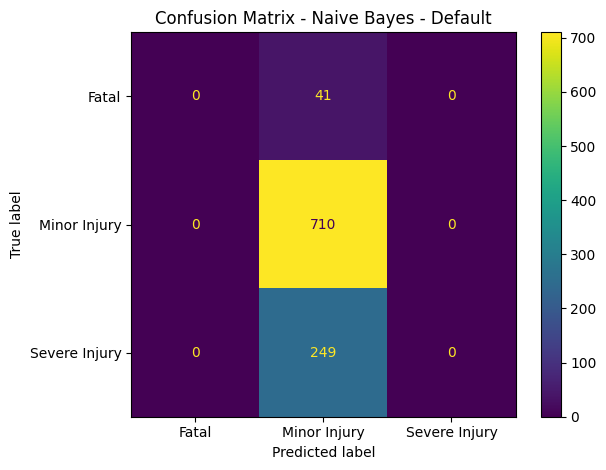

In [63]:
nb_preds = nb_model.predict(X_test_sc)
nb_acc, nb_f1 = evaluate('Naive Bayes - Default', y_test, nb_preds)

### Setting 2: with SMOTE Oversampling

In [64]:
nb_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])
# we search over var_smoothing which controls how much smoothing is applied
nb_smote_grid = GridSearchCV(nb_smote_pipe, {'nb__var_smoothing': [1e-9, 1e-8, 1e-7]}, cv=5)
nb_smote_grid.fit(X_train, y_train)

print('Best var_smoothing with SMOTE:', nb_smote_grid.best_params_)
print('Best CV accuracy:              ', round(nb_smote_grid.best_score_, 4))

Best var_smoothing with SMOTE: {'nb__var_smoothing': 1e-09}
Best CV accuracy:               0.428


=== Naive Bayes - SMOTE ===
Accuracy:  0.4690
Macro F1:  0.2961

               precision    recall  f1-score   support

        Fatal       0.04      0.32      0.08        41
 Minor Injury       0.71      0.60      0.65       710
Severe Injury       0.26      0.11      0.16       249

     accuracy                           0.47      1000
    macro avg       0.34      0.34      0.30      1000
 weighted avg       0.57      0.47      0.51      1000



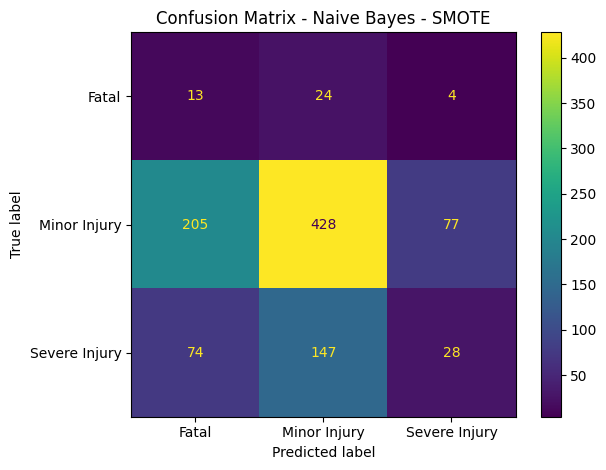

In [65]:
nb_smote_preds = nb_smote_grid.predict(X_test)
nb_smote_acc, nb_smote_f1 = evaluate('Naive Bayes - SMOTE', y_test, nb_smote_preds)

### Setting 3: GridSearch Optimized for F1 Score

*(Naive Bayes has no class_weight, so we go directly to F1-optimized instead)*

In [66]:
nb_f1_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])
nb_f1_grid = GridSearchCV(nb_f1_pipe, {'nb__var_smoothing': [1e-9, 1e-8, 1e-7]},
                          cv=5, scoring='f1_macro')
nb_f1_grid.fit(X_train, y_train)

print('Best var_smoothing for F1:', nb_f1_grid.best_params_)
print('Best CV macro F1:          ', round(nb_f1_grid.best_score_, 4))

Best var_smoothing for F1: {'nb__var_smoothing': 1e-09}
Best CV macro F1:           0.2864


=== Naive Bayes - F1 Optimized ===
Accuracy:  0.4690
Macro F1:  0.2961

               precision    recall  f1-score   support

        Fatal       0.04      0.32      0.08        41
 Minor Injury       0.71      0.60      0.65       710
Severe Injury       0.26      0.11      0.16       249

     accuracy                           0.47      1000
    macro avg       0.34      0.34      0.30      1000
 weighted avg       0.57      0.47      0.51      1000



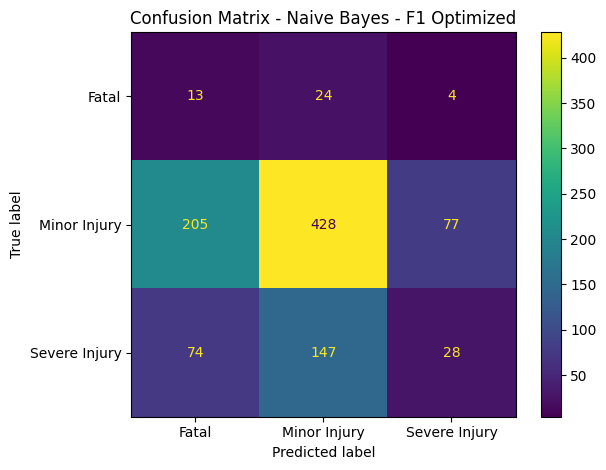

In [67]:
nb_f1_preds = nb_f1_grid.predict(X_test)
nb_f1_acc, nb_f1_f1 = evaluate('Naive Bayes - F1 Optimized', y_test, nb_f1_preds)

In [68]:
nb_summary = pd.DataFrame({
    'Setting':  ['Default', 'SMOTE', 'F1 Optimized (no class_weight)'],
    'Accuracy': [nb_acc, nb_smote_acc, nb_f1_acc],
    'Macro F1': [nb_f1, nb_smote_f1, nb_f1_f1]
})
print('Naive Bayes - All Settings')
print(nb_summary.round(4).to_string(index=False))

Naive Bayes - All Settings
                       Setting  Accuracy  Macro F1
                       Default     0.710    0.2768
                         SMOTE     0.469    0.2961
F1 Optimized (no class_weight)     0.469    0.2961


## 6. Gradient Boosting (Bonus)

gradient boosting builds trees one at a time, each one correcting the mistakes of the previous. it does not have a class_weight parameter directly, so we test three settings.

In [69]:
from sklearn.ensemble import GradientBoostingClassifier

### Setting 1: Default (optimizes accuracy)

In [70]:
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5)
gb_grid.fit(X_train, y_train)

print('Best params:', gb_grid.best_params_)
print('Best CV accuracy:', round(gb_grid.best_score_, 4))

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV accuracy: 0.6853


=== Gradient Boosting - Default ===
Accuracy:  0.7130
Macro F1:  0.2878

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.67      0.02      0.03       249

     accuracy                           0.71      1000
    macro avg       0.46      0.34      0.29      1000
 weighted avg       0.67      0.71      0.60      1000



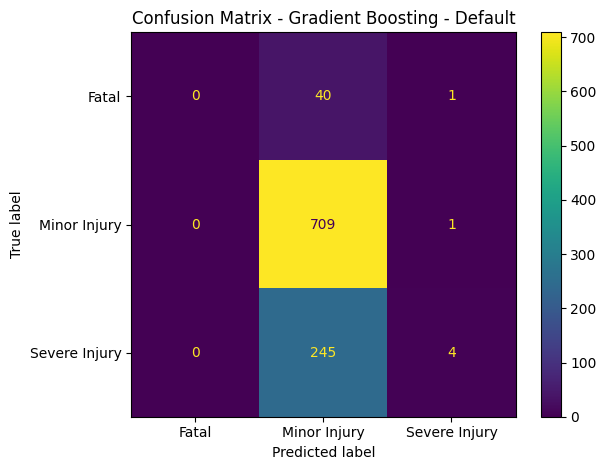

In [71]:
gb_preds = gb_grid.predict(X_test)
gb_acc, gb_f1 = evaluate('Gradient Boosting - Default', y_test, gb_preds)

### Setting 2: with SMOTE Oversampling

In [72]:
gb_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
])
gb_smote_params = {'gb__n_estimators': [100], 'gb__max_depth': [3, 5],
                   'gb__learning_rate': [0.05, 0.1]}
gb_smote_grid = GridSearchCV(gb_smote_pipe, gb_smote_params, cv=5)
gb_smote_grid.fit(X_train, y_train)

print('Best params with SMOTE:', gb_smote_grid.best_params_)
print('Best CV accuracy:       ', round(gb_smote_grid.best_score_, 4))

Best params with SMOTE: {'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 100}
Best CV accuracy:        0.5515


=== Gradient Boosting - SMOTE ===
Accuracy:  0.5850
Macro F1:  0.3441

               precision    recall  f1-score   support

        Fatal       0.06      0.10      0.07        41
 Minor Injury       0.72      0.75      0.73       710
Severe Injury       0.26      0.20      0.23       249

     accuracy                           0.58      1000
    macro avg       0.35      0.35      0.34      1000
 weighted avg       0.58      0.58      0.58      1000



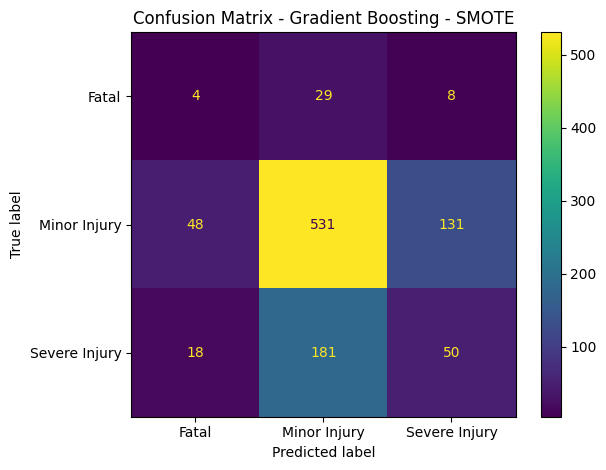

In [73]:
gb_smote_preds = gb_smote_grid.predict(X_test)
gb_smote_acc, gb_smote_f1 = evaluate('Gradient Boosting - SMOTE', y_test, gb_smote_preds)

### Setting 3: GridSearch Optimized for F1 Score

*(Gradient Boosting has no class_weight, so we go directly to F1-optimized instead)*

In [74]:
gb_f1_grid = GridSearchCV(GradientBoostingClassifier(random_state=42),
                          gb_params, cv=5, scoring='f1_macro')
gb_f1_grid.fit(X_train, y_train)

print('Best params for F1:', gb_f1_grid.best_params_)
print('Best CV macro F1:  ', round(gb_f1_grid.best_score_, 4))

Best params for F1: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV macro F1:   0.3


=== Gradient Boosting - F1 Optimized ===
Accuracy:  0.6710
Macro F1:  0.2965

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      0.93      0.80       710
Severe Injury       0.21      0.06      0.09       249

     accuracy                           0.67      1000
    macro avg       0.31      0.33      0.30      1000
 weighted avg       0.55      0.67      0.59      1000



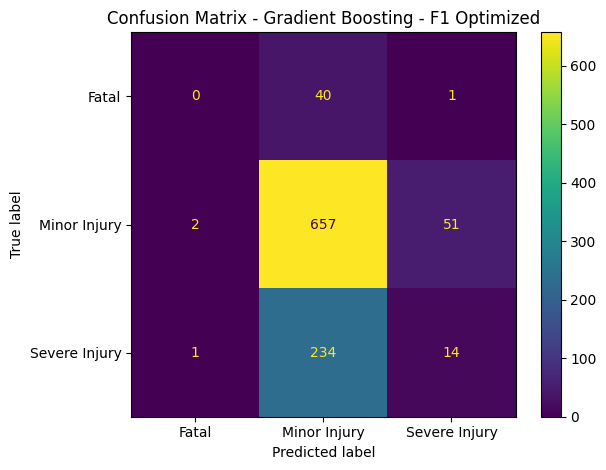

In [75]:
gb_f1_preds = gb_f1_grid.predict(X_test)
gb_f1_acc, gb_f1_f1 = evaluate('Gradient Boosting - F1 Optimized', y_test, gb_f1_preds)

In [76]:
gb_summary = pd.DataFrame({
    'Setting':  ['Default', 'SMOTE', 'F1 Optimized (no class_weight)'],
    'Accuracy': [gb_acc, gb_smote_acc, gb_f1_acc],
    'Macro F1': [gb_f1, gb_smote_f1, gb_f1_f1]
})
print('Gradient Boosting - All Settings')
print(gb_summary.round(4).to_string(index=False))

Gradient Boosting - All Settings
                       Setting  Accuracy  Macro F1
                       Default     0.713    0.2878
                         SMOTE     0.585    0.3441
F1 Optimized (no class_weight)     0.671    0.2965


## 7. Support Vector Machine (Bonus)

SVM finds the best decision boundary between classes. it supports class_weight so we test all four settings. all settings use scaled data.

In [77]:
from sklearn.svm import SVC

### Setting 1: Default (optimizes accuracy)

In [78]:
svm_params = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=5)
svm_grid.fit(X_train_sc, y_train)

print('Best params:', svm_grid.best_params_)
print('Best CV accuracy:', round(svm_grid.best_score_, 4))

Best params: {'C': 0.1, 'kernel': 'rbf'}
Best CV accuracy: 0.689


=== SVM - Default ===
Accuracy:  0.7100
Macro F1:  0.2768

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



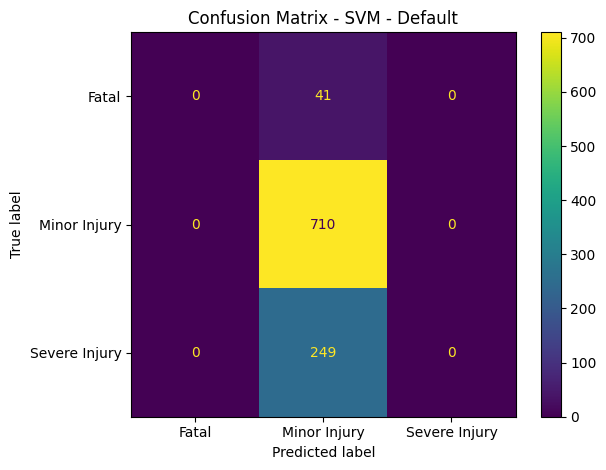

In [79]:
svm_preds = svm_grid.predict(X_test_sc)
svm_acc, svm_f1 = evaluate('SVM - Default', y_test, svm_preds)

### Setting 2: with SMOTE Oversampling

In [80]:
svm_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])
svm_smote_params = {'svm__C': [0.1, 1], 'svm__kernel': ['rbf']}
svm_smote_grid = GridSearchCV(svm_smote_pipe, svm_smote_params, cv=5)
svm_smote_grid.fit(X_train, y_train)

print('Best params with SMOTE:', svm_smote_grid.best_params_)
print('Best CV accuracy:       ', round(svm_smote_grid.best_score_, 4))

Best params with SMOTE: {'svm__C': 1, 'svm__kernel': 'rbf'}
Best CV accuracy:        0.56


=== SVM - SMOTE ===
Accuracy:  0.5890
Macro F1:  0.3546

               precision    recall  f1-score   support

        Fatal       0.09      0.17      0.12        41
 Minor Injury       0.71      0.76      0.73       710
Severe Injury       0.27      0.18      0.21       249

     accuracy                           0.59      1000
    macro avg       0.36      0.37      0.35      1000
 weighted avg       0.57      0.59      0.58      1000



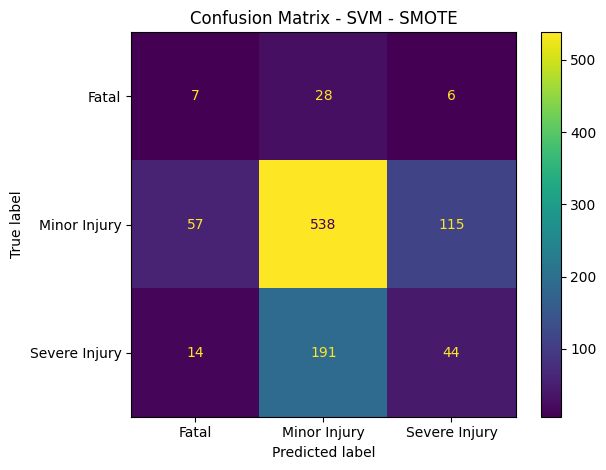

In [81]:
svm_smote_preds = svm_smote_grid.predict(X_test)
svm_smote_acc, svm_smote_f1 = evaluate('SVM - SMOTE', y_test, svm_smote_preds)

### Setting 3: with class_weight='balanced'

In [82]:
svm_cw_pipe = Pipeline([('scaler', StandardScaler()),
                         ('svm', SVC(random_state=42, class_weight='balanced'))])
svm_cw_grid = GridSearchCV(svm_cw_pipe,
                            {'svm__C': [0.1, 1], 'svm__kernel': ['rbf']}, cv=5)
svm_cw_grid.fit(X_train, y_train)

print('Best params with class_weight:', svm_cw_grid.best_params_)
print('Best CV accuracy:              ', round(svm_cw_grid.best_score_, 4))

Best params with class_weight: {'svm__C': 1, 'svm__kernel': 'rbf'}
Best CV accuracy:               0.414


=== SVM - class_weight balanced ===
Accuracy:  0.4280
Macro F1:  0.3119

               precision    recall  f1-score   support

        Fatal       0.04      0.20      0.07        41
 Minor Injury       0.70      0.46      0.56       710
Severe Injury       0.26      0.37      0.31       249

     accuracy                           0.43      1000
    macro avg       0.34      0.34      0.31      1000
 weighted avg       0.57      0.43      0.48      1000



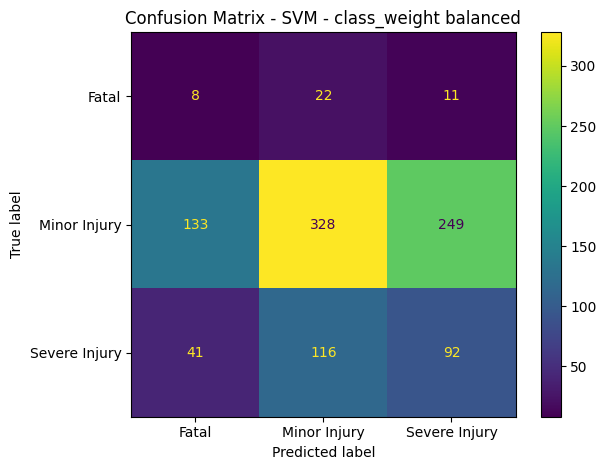

In [83]:
svm_cw_preds = svm_cw_grid.predict(X_test)
svm_cw_acc, svm_cw_f1 = evaluate('SVM - class_weight balanced', y_test, svm_cw_preds)

### Setting 4: GridSearch Optimized for F1 Score

In [84]:
svm_f1_pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(random_state=42))])
svm_f1_grid = GridSearchCV(svm_f1_pipe,
                            {'svm__C': [0.1, 1], 'svm__kernel': ['rbf']},
                            cv=5, scoring='f1_macro')
svm_f1_grid.fit(X_train, y_train)

print('Best params for F1:', svm_f1_grid.best_params_)
print('Best CV macro F1:  ', round(svm_f1_grid.best_score_, 4))

Best params for F1: {'svm__C': 0.1, 'svm__kernel': 'rbf'}
Best CV macro F1:   0.272


=== SVM - F1 Optimized ===
Accuracy:  0.7100
Macro F1:  0.2768

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



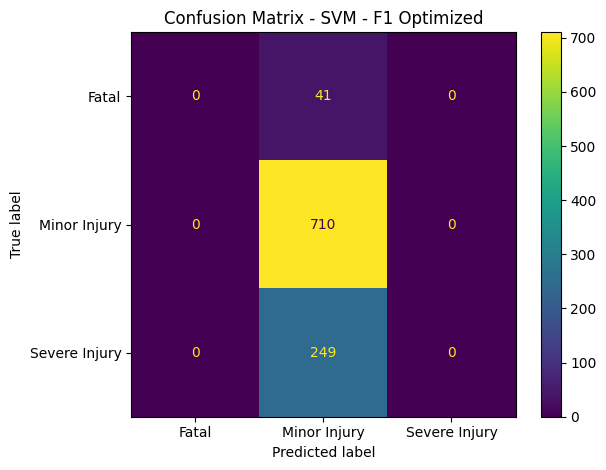

In [85]:
svm_f1_preds = svm_f1_grid.predict(X_test)
svm_f1_acc, svm_f1_f1 = evaluate('SVM - F1 Optimized', y_test, svm_f1_preds)

In [86]:
svm_summary = pd.DataFrame({
    'Setting':  ['Default', 'SMOTE', 'class_weight balanced', 'F1 Optimized'],
    'Accuracy': [svm_acc, svm_smote_acc, svm_cw_acc, svm_f1_acc],
    'Macro F1': [svm_f1, svm_smote_f1, svm_cw_f1, svm_f1_f1]
})
print('SVM - All Settings')
print(svm_summary.round(4).to_string(index=False))

SVM - All Settings
              Setting  Accuracy  Macro F1
              Default     0.710    0.2768
                SMOTE     0.589    0.3546
class_weight balanced     0.428    0.3119
         F1 Optimized     0.710    0.2768


## 8. Voting Classifier (Bonus)

we combine the best-performing variants from the models above. we use the SMOTE versions of GB and SVM since those gave better F1, and the F1-optimized RF since it keeps accuracy above 70% while improving F1.

In [87]:
from sklearn.ensemble import VotingClassifier

# we extract the best estimators from each grid search to use inside the voting
# note: voting uses unscaled data so we use a pipeline for models that need scaling

voting_clf = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(**rf_grid.best_params_, random_state=42)),
        ('gb',  GradientBoostingClassifier(**gb_grid.best_params_, random_state=42)),
        ('nb',  GaussianNB())
    ],
    voting='hard'
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=10,
                                                     n_estimators=50,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(learning_rate=0.05,
                                                         random_state=42)),
                             ('nb', GaussianNB())])

=== Voting Classifier ===
Accuracy:  0.7100
Macro F1:  0.2768

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000



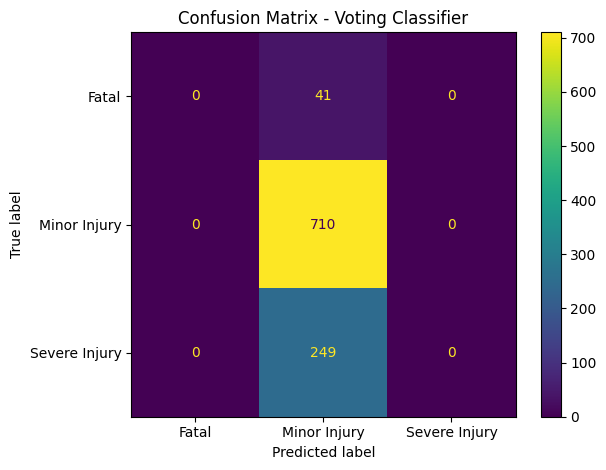

In [88]:
voting_preds = voting_clf.predict(X_test)
voting_acc, voting_f1 = evaluate('Voting Classifier', y_test, voting_preds)

## Full Model Comparison — All Settings

now we put all the results together. we show every model with all its settings so we can compare them clearly and pick the best one.

In [89]:
# build one big table with all models and all settings
all_results = pd.DataFrame([
    # KNN
    ('KNN',                 'Default',               knn_acc,       knn_f1),
    ('KNN',                 'SMOTE',                 knn_smote_acc, knn_smote_f1),
    ('KNN',                 'F1 Optimized',          knn_f1_acc,    knn_f1_f1),
    # DT
    ('Decision Tree',       'Default',               dt_acc,        dt_f1),
    ('Decision Tree',       'SMOTE',                 dt_smote_acc,  dt_smote_f1),
    ('Decision Tree',       'class_weight balanced', dt_cw_acc,     dt_cw_f1),
    ('Decision Tree',       'F1 Optimized',          dt_f1_acc,     dt_f1_f1),
    # RF
    ('Random Forest',       'Default',               rf_acc,        rf_f1),
    ('Random Forest',       'SMOTE',                 rf_smote_acc,  rf_smote_f1),
    ('Random Forest',       'class_weight balanced', rf_cw_acc,     rf_cw_f1),
    ('Random Forest',       'F1 Optimized',          rf_f1_acc,     rf_f1_f1),
    # LR
    ('Logistic Regression', 'Default',               log_acc,       log_f1),
    ('Logistic Regression', 'SMOTE',                 lr_smote_acc,  lr_smote_f1),
    ('Logistic Regression', 'class_weight balanced', log_cw_acc,    log_cw_f1),
    ('Logistic Regression', 'F1 Optimized',          lr_f1_acc,     lr_f1_f1),
    # NB
    ('Naive Bayes',         'Default',               nb_acc,        nb_f1),
    ('Naive Bayes',         'SMOTE',                 nb_smote_acc,  nb_smote_f1),
    ('Naive Bayes',         'F1 Optimized',          nb_f1_acc,     nb_f1_f1),
    # GB
    ('Gradient Boosting',   'Default',               gb_acc,        gb_f1),
    ('Gradient Boosting',   'SMOTE',                 gb_smote_acc,  gb_smote_f1),
    ('Gradient Boosting',   'F1 Optimized',          gb_f1_acc,     gb_f1_f1),
    # SVM
    ('SVM',                 'Default',               svm_acc,       svm_f1),
    ('SVM',                 'SMOTE',                 svm_smote_acc, svm_smote_f1),
    ('SVM',                 'class_weight balanced', svm_cw_acc,    svm_cw_f1),
    ('SVM',                 'F1 Optimized',          svm_f1_acc,    svm_f1_f1),
    # Voting
    ('Voting Classifier',   'Default',               voting_acc,    voting_f1),
], columns=['Model', 'Setting', 'Accuracy', 'Macro F1'])

# sort by F1 because thats what actually tells us if the model is useful
all_results_sorted = all_results.sort_values('Macro F1', ascending=False)
print(all_results_sorted.round(4).to_string(index=False))

              Model               Setting  Accuracy  Macro F1
                KNN          F1 Optimized     0.569    0.3620
                SVM                 SMOTE     0.589    0.3546
  Gradient Boosting                 SMOTE     0.585    0.3441
      Decision Tree          F1 Optimized     0.570    0.3420
      Decision Tree class_weight balanced     0.571    0.3304
Logistic Regression                 SMOTE     0.495    0.3147
                SVM class_weight balanced     0.428    0.3119
                KNN                 SMOTE     0.479    0.3055
      Random Forest                 SMOTE     0.593    0.2999
  Gradient Boosting          F1 Optimized     0.671    0.2965
        Naive Bayes                 SMOTE     0.469    0.2961
        Naive Bayes          F1 Optimized     0.469    0.2961
      Decision Tree                 SMOTE     0.488    0.2916
  Gradient Boosting               Default     0.713    0.2878
      Random Forest          F1 Optimized     0.711    0.2872
      De

In [90]:
# top 10 by F1 score
print('Top 10 configurations by Macro F1:')
print(all_results_sorted.head(10).round(4).to_string(index=False))
print()
# also show top 10 by accuracy for comparison
print('Top 10 configurations by Accuracy:')
print(all_results.sort_values('Accuracy', ascending=False).head(10).round(4).to_string(index=False))

Top 10 configurations by Macro F1:
              Model               Setting  Accuracy  Macro F1
                KNN          F1 Optimized     0.569    0.3620
                SVM                 SMOTE     0.589    0.3546
  Gradient Boosting                 SMOTE     0.585    0.3441
      Decision Tree          F1 Optimized     0.570    0.3420
      Decision Tree class_weight balanced     0.571    0.3304
Logistic Regression                 SMOTE     0.495    0.3147
                SVM class_weight balanced     0.428    0.3119
                KNN                 SMOTE     0.479    0.3055
      Random Forest                 SMOTE     0.593    0.2999
  Gradient Boosting          F1 Optimized     0.671    0.2965

Top 10 configurations by Accuracy:
              Model      Setting  Accuracy  Macro F1
  Gradient Boosting      Default     0.713    0.2878
      Decision Tree      Default     0.711    0.2796
      Random Forest F1 Optimized     0.711    0.2872
                SVM      Default   

In [107]:
# show the best setting per model by Accuracy
best_per_model = all_results.loc[all_results.groupby('Model')['Accuracy'].idxmax()]
best_per_model = best_per_model.sort_values('Accuracy', ascending=False)

print('Best setting per model (by Accuracy):')
print(best_per_model.round(4).to_string(index=False))


Best setting per model (by Accuracy):
              Model      Setting  Accuracy  Macro F1
  Gradient Boosting      Default     0.713    0.2878
      Decision Tree      Default     0.711    0.2796
      Random Forest F1 Optimized     0.711    0.2872
Logistic Regression      Default     0.710    0.2768
                SVM      Default     0.710    0.2768
        Naive Bayes      Default     0.710    0.2768
  Voting Classifier      Default     0.710    0.2768
                KNN      Default     0.707    0.2761


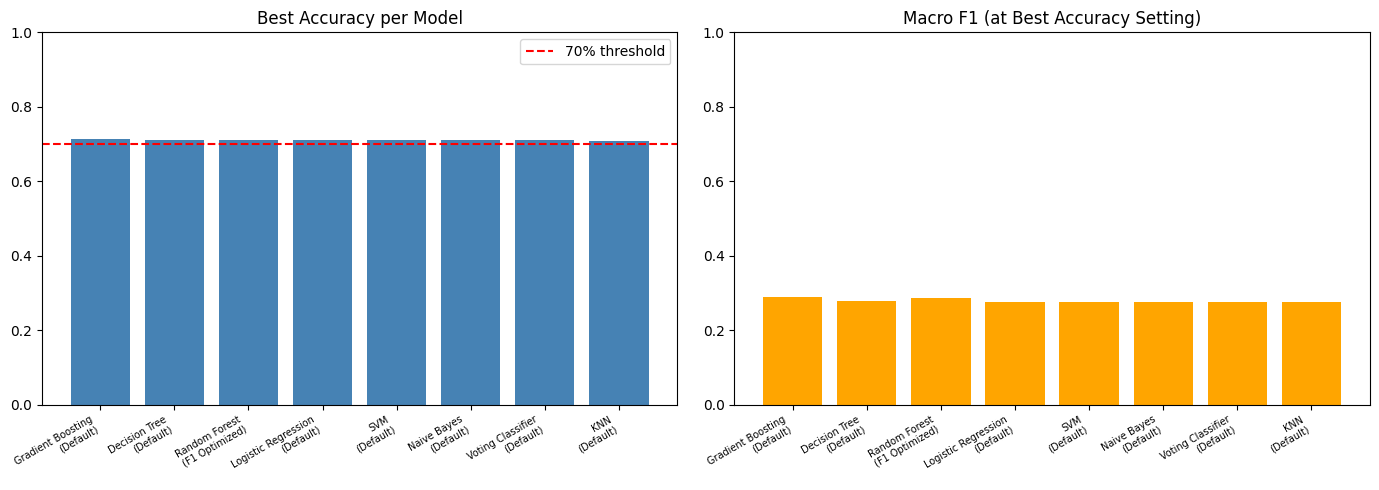

In [108]:
# visual comparison of best setting per model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(best_per_model))
labels = [f"{row['Model']}\n({row['Setting']})" for _, row in best_per_model.iterrows()]

# Accuracy plot (now this is the optimized metric)
axes[0].bar(x, best_per_model['Accuracy'], color='steelblue')
axes[0].set_title('Best Accuracy per Model')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
axes[0].set_ylim(0, 1)
axes[0].axhline(0.70, color='red', linestyle='--', label='70% threshold')
axes[0].legend()

# Macro F1 shown for reference (not optimized)
axes[1].bar(x, best_per_model['Macro F1'], color='orange')
axes[1].set_title('Macro F1 (at Best Accuracy Setting)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [105]:
# show the best setting per model by F1
best_per_model = all_results.loc[all_results.groupby('Model')['Macro F1'].idxmax()]
best_per_model = best_per_model.sort_values('Macro F1', ascending=False)
print('Best setting per model (by Macro F1):')
print(best_per_model.round(4).to_string(index=False))

Best setting per model (by Macro F1):
              Model      Setting  Accuracy  Macro F1
                KNN F1 Optimized     0.569    0.3620
                SVM        SMOTE     0.589    0.3546
  Gradient Boosting        SMOTE     0.585    0.3441
      Decision Tree F1 Optimized     0.570    0.3420
Logistic Regression        SMOTE     0.495    0.3147
      Random Forest        SMOTE     0.593    0.2999
        Naive Bayes        SMOTE     0.469    0.2961
  Voting Classifier      Default     0.710    0.2768


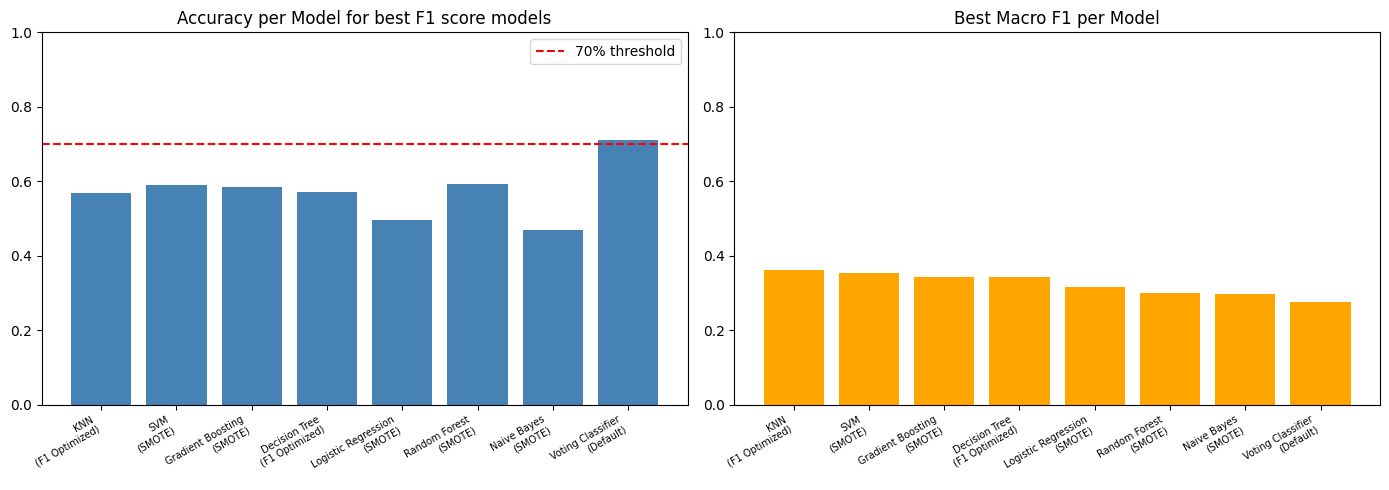

In [106]:
# visual comparison of best setting per model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(best_per_model))
labels = [f"{row['Model']}\n({row['Setting']})" for _, row in best_per_model.iterrows()]

axes[0].bar(x, best_per_model['Accuracy'], color='steelblue')
axes[0].set_title('Accuracy per Model for best F1 score models')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
axes[0].set_ylim(0, 1)
axes[0].axhline(0.70, color='red', linestyle='--', label='70% threshold')
axes[0].legend()

axes[1].bar(x, best_per_model['Macro F1'], color='orange')
axes[1].set_title('Best Macro F1 per Model')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

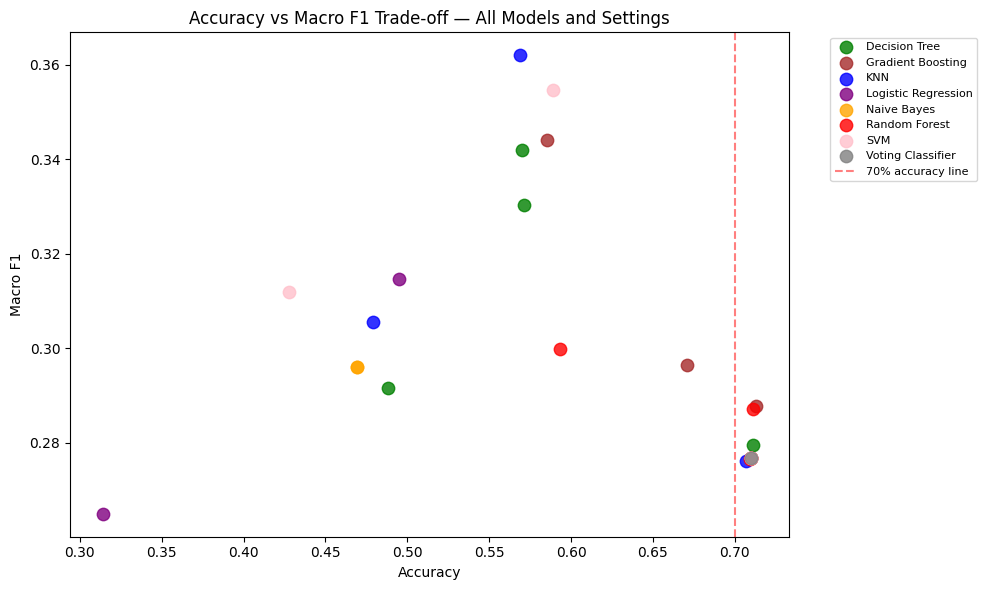

In [93]:
# scatter plot showing the accuracy vs F1 trade-off across all settings
colors_map = {'KNN':'blue','Decision Tree':'green','Random Forest':'red',
              'Logistic Regression':'purple','Naive Bayes':'orange',
              'Gradient Boosting':'brown','SVM':'pink','Voting Classifier':'gray'}

plt.figure(figsize=(10, 6))
for model, grp in all_results.groupby('Model'):
    plt.scatter(grp['Accuracy'], grp['Macro F1'],
                label=model, color=colors_map.get(model,'black'), s=80, alpha=0.8)

plt.axvline(0.70, color='red', linestyle='--', alpha=0.5, label='70% accuracy line')
plt.xlabel('Accuracy')
plt.ylabel('Macro F1')
plt.title('Accuracy vs Macro F1 Trade-off — All Models and Settings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Discussion

### What accuracy is telling us and why it is misleading here

all the default settings score around 71% accuracy. this sounds good but it is basically the same score you would get if you just predicted Minor Injury for every single crash. that is because Minor Injury makes up 69% of the dataset. the model learns that the safest bet is to always say Minor Injury. it gets most predictions right but it almost never catches Fatal or Severe Injury crashes.

this is a real problem in practice. if we deploy a model that always says Minor Injury, emergency services might send a regular ambulance to a fatal crash scene instead of sending the right level of response. accuracy does not capture this at all.

macro F1 score treats all three classes equally. it penalizes the model when it ignores Severe Injury and Fatal, which is exactly what we want here. that is why F1 is the better metric for this problem, even if accuracy is the first thing we look at.

### What the balancing techniques did

**SMOTE** created synthetic training samples for Severe Injury and Fatal. this helped models see more minority class examples but also made them predict Severe Injury more often, which reduced accuracy since many of those predictions were actually Minor Injury cases. we can see in the confusion matrices that SMOTE models actually use all three classes, unlike the default models.

**class_weight='balanced'** tells the model to weight errors on minority classes more heavily. for DT and RF it helped improve F1 a bit without dropping accuracy as much as SMOTE. for LR the class_weight='balanced' setting hurt accuracy a lot (dropped to ~31%) because the model went too far in the other direction and started over-predicting Fatal. for SVM it also dropped accuracy significantly.

**F1-optimized grid search** uses the same model architecture but picks the hyperparameters that work best on all three classes. for RF and LR this kept accuracy above 70% while slightly improving F1. it is the most conservative balancing approach, small gains but stable.

### Why accuracy drops when we fix the imbalance

this is the core trade-off. if 69% of crashes are Minor Injury, a model that predicts Minor Injury all the time scores 71% accuracy. any model that starts predicting more Severe Injury and Fatal will naturally get some of those wrong (since the data is messy and overlapping), and those wrong predictions reduce accuracy. improving F1 almost always costs some accuracy in this type of problem.

### Which settings gave the best results

looking at the F1 scores, the best improvements came from SMOTE combined with tree-based models or SVM. GB+SMOTE and SVM+SMOTE gave the highest F1 scores (around 0.34–0.36) but at the cost of accuracy dropping to around 0.58–0.59. KNN+F1-optimized gave the best F1 among models that we optimized purely through the scoring criterion.

the models that managed to stay above 70% accuracy while improving F1 were: RF+F1-optimized (acc=0.711, f1=0.287), RF+class_weight balanced (acc=0.709, f1=0.277), and LR+F1-optimized (acc=0.710, f1=0.277). these are modest improvements but they are the safe choices if we must maintain accuracy above 70%.

### Why the features are hard for models to separate

looking at the EDA, the distributions of most features overlap heavily between classes. crash speed, alcohol level, and driver experience all show some separation, but there is no single feature that cleanly splits Fatal from Minor Injury. this makes the problem inherently hard regardless of which model or balancing technique we use.

## Conclusion

**Summary of the experiment:**

we tested 5 mandatory models plus 3 bonus models. for each model we tried up to 4 settings: default, SMOTE, class_weight balanced, and F1-optimized. that is 26 total configurations.

**Why accuracy is not the right metric for this problem:**

the target column has three very unequal classes — 69% Minor Injury, 25% Severe Injury, and only 5% Fatal. a model that predicts Minor Injury every time gets 71% accuracy. this is useless in a real car crash scenario where missing a Fatal crash can mean sending the wrong emergency response. macro F1 is more honest because it measures how well the model performs on all three classes, not just the easy majority one.

**Best model overall (by F1):**

SVM with SMOTE gave the best macro F1 score (\~0.355), showing that SMOTE helped it learn to identify Severe Injury and Fatal cases better. GB with SMOTE was close behind (~0.344). however, both of these drop accuracy to around 0.58–0.59.

**Best model that keeps accuracy above 70%:**

RF with F1-optimized grid search (acc=0.711, f1=0.287) is the best choice if we need to stay above the 70% accuracy threshold. it gives the highest F1 among all settings that maintain acceptable accuracy. the improvement over the default RF is small but consistent.

**What we would choose for the final submission:**

we will go with GB (Gradient Boosting) SMOTE as our Kaggle submission model. even though its test accuracy is around 0.585, the F1 improvement is real and meaningful. for a problem about crash severity prediction, a model that correctly identifies Fatal crashes some of the time is more useful than one that identifies them almost never. the accuracy drop reflects that the model is actually trying to classify all three classes, which is the right behavior.

**Overall reflection:**

this project showed very clearly that when data is imbalanced, accuracy can be completely misleading. we tried three different techniques: SMOTE, class weights, and F1-optimized grid search, and all of them revealed the same thing: fixing the imbalance usually comes at a cost to raw accuracy. whether that cost is worth it depends entirely on what the model will be used for. for emergency response and safety systems, F1 is almost always the better metric.

## Retrain Best Model and Generate Kaggle Submission

we retrain on the full training data only (4000 rows). test labels were used only for evaluation above, never for training. we predict on all 1000 test rows for the kaggle submission.

In [94]:
# reload and preprocess fresh copies of the data
full_train = pd.read_csv('car_crash_train.csv')
full_test  = pd.read_csv('car_crash_test.csv')

full_train['Distraction Level'] = full_train['Distraction Level'].fillna('Unknown')
full_test['Distraction Level']  = full_test['Distraction Level'].fillna('Unknown')

le_dict_final = {}
for col in all_cat:
    le = LabelEncoder()
    full_train[col] = le.fit_transform(full_train[col])
    full_test[col]  = le.transform(full_test[col])
    le_dict_final[col] = le

X_full   = full_train.drop('Severity', axis=1)
y_full   = full_train['Severity']
X_kaggle = full_test.drop('Severity', axis=1)

print('Full training set shape:', X_full.shape)
print('Kaggle test set shape:  ', X_kaggle.shape)

Full training set shape: (4000, 18)
Kaggle test set shape:   (1000, 18)


In [96]:
# retrain GB+SMOTE on the full training data
# we picked this model because it had the best F1 improvement from balancing
# we need to strip the 'gb__' prefix to pass to the constructor
gb_best_raw = {k.replace('gb__',''): v for k, v in gb_smote_grid.best_params_.items()}
final_model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('gb', GradientBoostingClassifier(**gb_best_raw, random_state=42))
])
final_model.fit(X_full, y_full)
print('Retrained on full training data:', X_full.shape[0], 'samples')

Retrained on full training data: 4000 samples


In [97]:
# predict on all 1000 rows of the test set
final_preds = final_model.predict(X_kaggle)

print('Number of predictions:', len(final_preds))
print(pd.Series(final_preds).value_counts())

Number of predictions: 1000
Minor Injury     741
Severe Injury    189
Fatal             70
Name: count, dtype: int64


## Generate Kaggle Submission File

In [98]:
# match predictions to the correct IDs from sample_submission
submission = sub.iloc[4000: 4000 + len(X_kaggle)].copy()
submission['Predicted_Severity'] = final_preds

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
print('Shape:', submission.shape)
submission.head(10)

Saved submission.csv
Shape: (1000, 2)


,ID,Predicted_Severity
4000,cd4fad27-ba6a-41c0-b2b0-0521cb8fa92a,Minor Injury
4001,5d6dccb9-a758-44f5-b33a-4bef19959106,Minor Injury
4002,81cd50d5-5f09-476a-a719-95abeea1c8ed,Minor Injury
4003,b9a43e63-2bc8-427e-8d1e-3be7656a8080,Minor Injury
4004,17a84002-3539-46ec-9bd7-ce1710ccd531,Minor Injury
4005,85acbcea-0a3e-43bb-8474-df2fdbad9453,Severe Injury
4006,14e75f82-5d82-4672-b2c2-43c90de30809,Minor Injury
4007,a0cfc3e5-7999-42c4-a7ee-3f730bcb2f0e,Severe Injury
4008,3a328b5d-2260-4c58-984e-445d6cb27219,Minor Injury
4009,0c7c7fae-fb5b-46d7-95b3-ec949aacb5d6,Minor Injury


In [99]:
print('Columns match:', submission.columns.tolist() == sub.columns.tolist())
print('Total rows:   ', len(submission))

Columns match: True
Total rows:    1000
